# 02 — Failure prediction

Trains and audits the models. The pipeline itself lives in `ml/train.py` so it
is testable and shared with live inference; this notebook runs it and
interprets the results.

Four decisions shape everything below:

1. **Split temporally and by room.** Rows five minutes apart are near-duplicates;
   a random shuffle would inflate scores to a meaningless ~0.99.
2. **Predict the fault *type*, not just failure.** The positive class is a
   mixture of three physically distinct faults dominated by one.
3. **Report a trivial baseline.** If a single threshold matches the model, the
   model earned nothing.
4. **Pick the threshold from a cost curve.** A missed failure and a wasted
   callout are not equally expensive.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import train as T
from features import FEATURE_COLUMNS
plt.rcParams["figure.figsize"] = (10, 4)
print(f"{len(FEATURE_COLUMNS)} features")

61 features


## Features exclude room identity — on purpose

`twin_id`, `floor`, `room_profile` and `segment_id` are all excluded, enforced
by test. In this data `f1/lab-a` fails 30× less often than the server room
purely because of its maintenance *policy*. An identity-aware model would learn
"lab-a is safe" and stay silent when its filter finally clogs.

Rolling windows are computed **per degradation segment**, so no window spans a
maintenance reset and smears a worn unit's history into a freshly serviced one.

In [2]:
print("excluded from features:", sorted(T_FORBIDDEN := __import__("features").FORBIDDEN))
print("\nexample features:", FEATURE_COLUMNS[:8], "...")

excluded from features: ['day', 'floor', 'label_failure_type', 'label_failure_within_30min', 'label_failure_within_4h', 'label_rul_hours', 'room_id', 'room_profile', 'segment_id', 'timestamp_iso', 'timestamp_s', 'twin_id']

example features: ['room_temp', 'humidity', 'occupancy', 'outdoor_temp', 'setpoint', 'ac_power_pct', 'hvac_on', 'motor_temp'] ...


## Load and split

In [3]:
df = T.load()
train, test_time, test_room, cutoff_day = T.split(df)
print(f"train      days 0-{cutoff_day}   {len(train):,} rows  {int(train[T.TARGET].sum()):,} positives")
print(f"test time  days {cutoff_day+1}+  {len(test_time):,} rows  {int(test_time[T.TARGET].sum()):,} positives")
print(f"test room  {T.HELD_OUT_ROOM} (never trained on)  {len(test_room):,} rows")

train      days 0-254   367,200 rows  6,340 positives
test time  days 255+  158,400 rows  2,833 positives
test room  f2/office (never trained on)  31,680 rows


In [4]:
x_train, y_train, f_train, m_train = T._matrix(train)
x_test,  y_test,  f_test,  m_test  = T._matrix(test_time)
x_room,  y_room,  f_room,  m_room  = T._matrix(test_room)
print("fault mix in training positives:")
print(pd.Series(f_train[f_train != "none"]).value_counts().to_string())

fault mix in training positives:
osf    6004
pwf     240
hdf      96


Only ~96 HDF rows — about **two events**. Remember that number; it explains the
model's one serious blind spot.

## Train and compare

In [5]:
models = T.train_models(x_train, f_train)
rows = []
for name, m in models.items():
    s = T.binary_scores(m, x_test)
    thr, cost = T.cost_optimal_threshold(y_test, s)
    ev = T.evaluate(name, y_test, s, thr)
    r90, _ = T.recall_at_precision(y_test, s, 0.90)
    rows.append(dict(model=name, pr_auc=round(ev.pr_auc,4), roc_auc=round(ev.roc_auc,4),
                     recall=round(ev.recall_at_threshold,4),
                     precision=round(ev.precision_at_threshold,4),
                     recall_at_p90=round(r90,4), threshold=round(thr,4),
                     expected_cost=round(cost)))
base_s, base_t = T.trivial_baseline(test_time)
be = T.evaluate("threshold motor_temp>80", y_test, base_s, base_t)
rows.insert(0, dict(model="threshold motor_temp>80", pr_auc=round(be.pr_auc,4),
                    roc_auc=round(be.roc_auc,4), recall=round(be.recall_at_threshold,4),
                    precision=round(be.precision_at_threshold,4)))
rows.insert(0, dict(model="always 'no failure'", pr_auc=round(float(y_test.mean()),4),
                    roc_auc=0.5, recall=0.0))
comparison = pd.DataFrame(rows); comparison

,model,pr_auc,roc_auc,recall,precision,recall_at_p90,threshold,expected_cost
0,always 'no failure',0.0179,0.5000,0.0000,NaN,NaN,NaN,NaN
1,threshold motor_temp>80,0.1634,0.7604,0.0092,0.2476,NaN,NaN,NaN
2,logistic_regression,0.5089,0.9742,0.9036,0.2559,0.0434,0.6547,1662600.0
3,random_forest,0.9341,0.9920,0.9467,0.5850,0.8563,0.1879,587450.0
4,gradient_boosting,0.9245,0.9962,0.9502,0.6644,0.8405,0.0053,486000.0


**Accuracy is absent from that table deliberately.** At a 1.7 % positive rate,
"always no failure" scores 98.3 % accuracy — the second row shows its PR-AUC is
0.018, which is the honest number.

The model beats the best single threshold by roughly 6× on PR-AUC, so it earns
its place. §"Per fault mode" below shows where that headline does *not* hold.

shipped model: gradient_boosting  threshold 0.0053


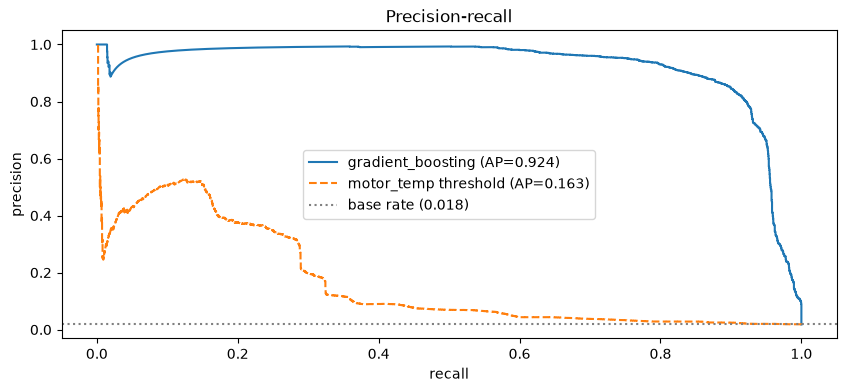

In [6]:
best_name = min([r["model"] for r in rows if "expected_cost" in r],
                key=lambda n: [r for r in rows if r["model"]==n][0]["expected_cost"])
best = models[best_name]
best_scores = T.binary_scores(best, x_test)
best_thr = [r for r in rows if r["model"]==best_name][0]["threshold"]
print(f"shipped model: {best_name}  threshold {best_thr}")

p, r, _ = precision_recall_curve(y_test, best_scores)
plt.plot(r, p, label=f"{best_name} (AP={average_precision_score(y_test,best_scores):.3f})")
pb, rb, _ = precision_recall_curve(y_test, base_s)
plt.plot(rb, pb, "--", label=f"motor_temp threshold (AP={average_precision_score(y_test,base_s):.3f})")
plt.axhline(y_test.mean(), color="grey", ls=":", label=f"base rate ({y_test.mean():.3f})")
plt.xlabel("recall"); plt.ylabel("precision"); plt.legend(); plt.title("Precision-recall"); plt.show()

## Cost curve — where the threshold comes from

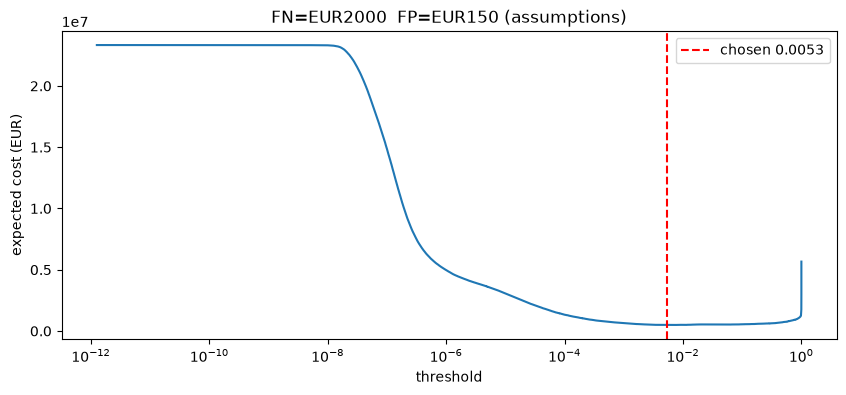

In [7]:
prec, rec, thr = precision_recall_curve(y_test, best_scores)
P = int(y_test.sum()); costs=[]
for i,t in enumerate(thr):
    tp = rec[i]*P; fn = P-tp
    fp = (tp/prec[i]-tp) if prec[i]>0 else len(y_test)-P
    costs.append(fn*T.COST_FALSE_NEGATIVE + fp*T.COST_FALSE_POSITIVE)
plt.semilogx(thr, costs); plt.axvline(best_thr, c="r", ls="--", label=f"chosen {best_thr}")
plt.xlabel("threshold"); plt.ylabel("expected cost (EUR)")
plt.title(f"FN=EUR{T.COST_FALSE_NEGATIVE:.0f}  FP=EUR{T.COST_FALSE_POSITIVE:.0f} (assumptions)")
plt.legend(); plt.show()

A 13:1 cost ratio pushes the threshold very low: the system is deliberately
tuned to over-call rather than miss. These costs are **assumptions**, and the
ROI case inherits that caveat.

## Per fault mode — the model's blind spot

In [8]:
modes = T.per_fault_report(best, x_test, y_test, f_test, best_thr, m_test)
modes

,fault,positives,recall_model,recall_hybrid,mean_model_score,note
0,hdf,97,0.0000,0.5876,0.0001,
1,osf,2640,0.9826,0.9826,0.9165,
2,pwf,96,1.0000,1.0000,0.6081,


**The model has 0.00 recall on heat-dissipation failure.**

It cannot be tuned away: there were ~2 HDF events in training. But HDF is
*defined* by motor temperature crossing the 85 °C insulation limit, so it has a
direct physical precursor — a threshold problem, not a learning problem.

The shipped system therefore runs a **physics guard** as an independent alarm
channel (a ramp from 70 °C to 85 °C), recovering recall to ~0.59. It is not
blended into the ML score: doing that dragged server-room precision from 0.81 to
0.33, because it fires on any hot motor regardless of fault.

**ML is not uniformly better than rules.** It beats any single threshold for
cumulative faults and loses to a thermostat for one with a direct precursor.

## Explainability

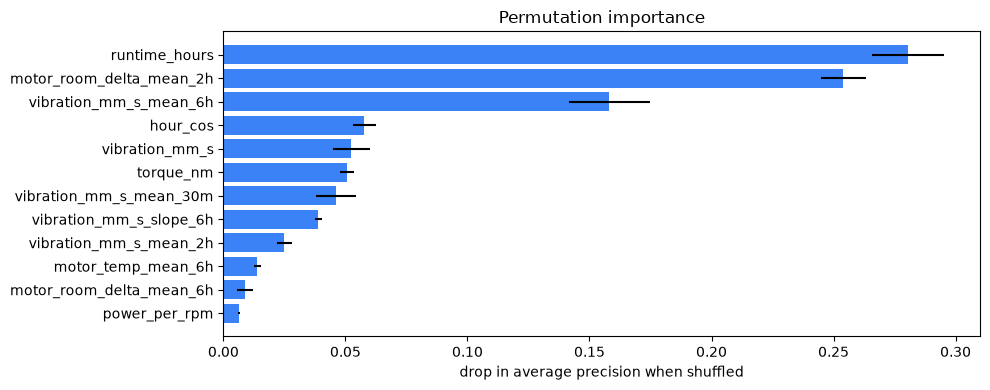

,feature,importance,std
0,runtime_hours,0.2805,0.0147
1,motor_room_delta_mean_2h,0.2539,0.0092
2,vibration_mm_s_mean_6h,0.1582,0.0165
3,hour_cos,0.0577,0.0048
4,vibration_mm_s,0.0524,0.0077
5,torque_nm,0.0507,0.0028
6,vibration_mm_s_mean_30m,0.0461,0.0083
7,vibration_mm_s_slope_6h,0.0388,0.0015
8,vibration_mm_s_mean_2h,0.0250,0.0030
9,motor_temp_mean_6h,0.0139,0.0015


In [9]:
imp = T.explain(best, x_test, f_test)
top = imp.head(12).iloc[::-1]
plt.barh(top.feature, top.importance, xerr=top["std"], color="#3b82f6")
plt.xlabel("drop in average precision when shuffled"); plt.title("Permutation importance")
plt.tight_layout(); plt.show()
imp.head(12).round(4)

Readable and consistent with the AI4I rules the physics was calibrated against:
`runtime_hours` is the overstrain driver, `motor_room_delta` is the
heat-dissipation driver, `vibration` is bearing condition.

`hour_cos` ranking highly is a caveat worth stating: the model has partly
learned *when the building is busy*, which will not transfer to a site on a
different schedule.

## Fairness audit

In [10]:
audit = T.fairness_audit(test_time, best, best_thr)
audit

,twin_id,rows,positives,positive_rate_pct,pr_auc,recall,precision,false_negative_rate,note
0,f1/lab-a,31680,97,0.306,0.0144,0.0000,0.0000,1.0000,
1,f1/lab-b,31680,288,0.909,0.8215,1.0000,0.4479,0.0000,
2,f1/server-room,31680,1344,4.242,0.9970,1.0000,0.8358,0.0000,
3,f2/lab-c,31680,768,2.424,0.8816,0.9427,0.5569,0.0573,
4,f2/meeting-room,31680,336,1.061,0.9891,0.9940,0.7167,0.0060,


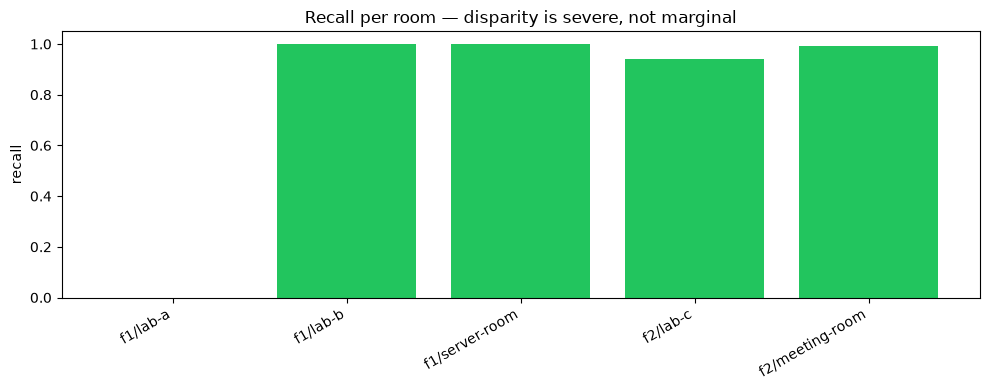

In [11]:
a = audit.dropna(subset=["recall"])
plt.bar(a.twin_id, a.recall, color=["#ef4444" if v<0.5 else "#22c55e" for v in a.recall])
plt.ylabel("recall"); plt.xticks(rotation=30, ha="right")
plt.title("Recall per room — disparity is severe, not marginal"); plt.tight_layout(); plt.show()

`f1/lab-a` has a **100 % false-negative rate**: every one of its failures is
missed.

The cause is not room identity — that is excluded from the features. It is that
lab-a is the most aggressively serviced unit, so it never accumulates the
runtime that produces overstrain; all its failures are HDF, the mode the model
cannot see. **Per-room disparity is per-mode disparity wearing a different hat.**

Who this harms matters: a wet lab holds temperature-sensitive samples, so the
model is blindest exactly where an outage costs most. Mitigation is the physics
guard (recall 0.000 → 0.536) plus publishing this table rather than averaging it
away. Even so, lab-a remains **inadequately covered** and should keep
calendar-based servicing.

## Generalisation to unseen equipment

In [12]:
room_scores = T.binary_scores(best, x_room)
ev = T.evaluate("unseen room", y_room, room_scores, best_thr)
print(f"{T.HELD_OUT_ROOM}: PR-AUC {ev.pr_auc:.4f}  recall {ev.recall_at_threshold:.4f}")
print(f"(seen rooms, same period: PR-AUC {average_precision_score(y_test, best_scores):.4f})")

f2/office: PR-AUC 0.2610  recall 0.5633
(seen rooms, same period: PR-AUC 0.9245)


Markedly worse on equipment it has never seen. A newly commissioned unit should
not be trusted to the same degree until it has contributed its own history.

## Remaining useful life

In [13]:
rul_model, rul_metrics = T.train_rul(train, test_time)
print(rul_metrics)
print(f"\nvs predict-the-mean baseline: {rul_metrics['baseline_mae_hours']} h")

{'mae_hours': 14.592, 'r2': 0.8121, 'n_train': 210526, 'n_test': 91590, 'baseline_mae_hours': 38.112}

vs predict-the-mean baseline: 38.112 h


MAE ≈ 15 hours against a 38-hour baseline. Trained only on uncensored rows —
rows pinned at the 168-hour censoring horizon are not observations of a real
remaining life, and training on them teaches the model to predict the censoring
constant.

## Conclusions

* The model earns its place for cumulative faults: PR-AUC 0.92 vs 0.16 for the
  best single threshold.
* It is **blind to heat-dissipation failure** (~2 training events) and needs a
  physics guard to cover it.
* Severe per-room disparity, driven by per-mode segregation, in the room where
  failure costs most.
* Everything here is trained on **simulated** telemetry. AI4I constrains the
  failure physics so the thresholds are not invented, but real deployment needs
  recalibration on ≥ 3 months of real data first.

Full limitations: [`ml/models/model_card.md`](../models/model_card.md).